# Study of origins of replication

### Datasets:
- Belsky set of origins with annotations for early/late replication timing, origin efficiency, footprint evidence, and nucleosome signals.
- Estimated replication timing.
- Deconvolved chromatin occupancy data.

### Ideas:
- Show the origin timing is linked to estimated replication timing.
- Show that we can analyze footprint, and nucleosome movement timing globally.
- Show a global timecourse representation.
- Show early and late examples.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [191]:
from pipeline.fig_origins import FigureOrigins

fig_origins = FigureOrigins('output/draft4_run/')

Creating directory: output/draft4_run//figure_origins...


In [197]:
fig_origins.setup_data()

Filtering the called replication timings to 1.0 percentile (highest timing indicative of poor fit)
Filtered timings from 5482 to 5370
Number of regions removed: 112
Correlation between muller and replication timing model: 0.87


In [605]:
# 1. Replication Timing Estimates Are Accurate - Strong Literature Agreement
# 2. Inferred origin firing from replication timing works
fig_origins.setup_processors(force_recompute=True)

Creating directory: output/draft4_run//figure_origins/metrics...Directory exists. Skipping.
Starting batch processing of 437 origins...
Detected 257 timepoints from sample origin oridb_5
1/437 00:00:00.449
101/437 00:00:44.267
201/437 00:01:26.448
301/437 00:02:08.763
401/437 00:02:50.315
Completed processing 437 origins!
Saving results to disk...
Results saved to output/draft4_run//figure_origins/metrics/
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints


In [ ]:
fig_origins.plot_all()

In [674]:
fig_origins.layout_panel()

Debug figure saved to: output/draft4_run//Figures/Supplemental5.7_Origins_debug.png
Clean figure saved to: output/draft4_run//Figures/Supplemental5.7_Origins.png


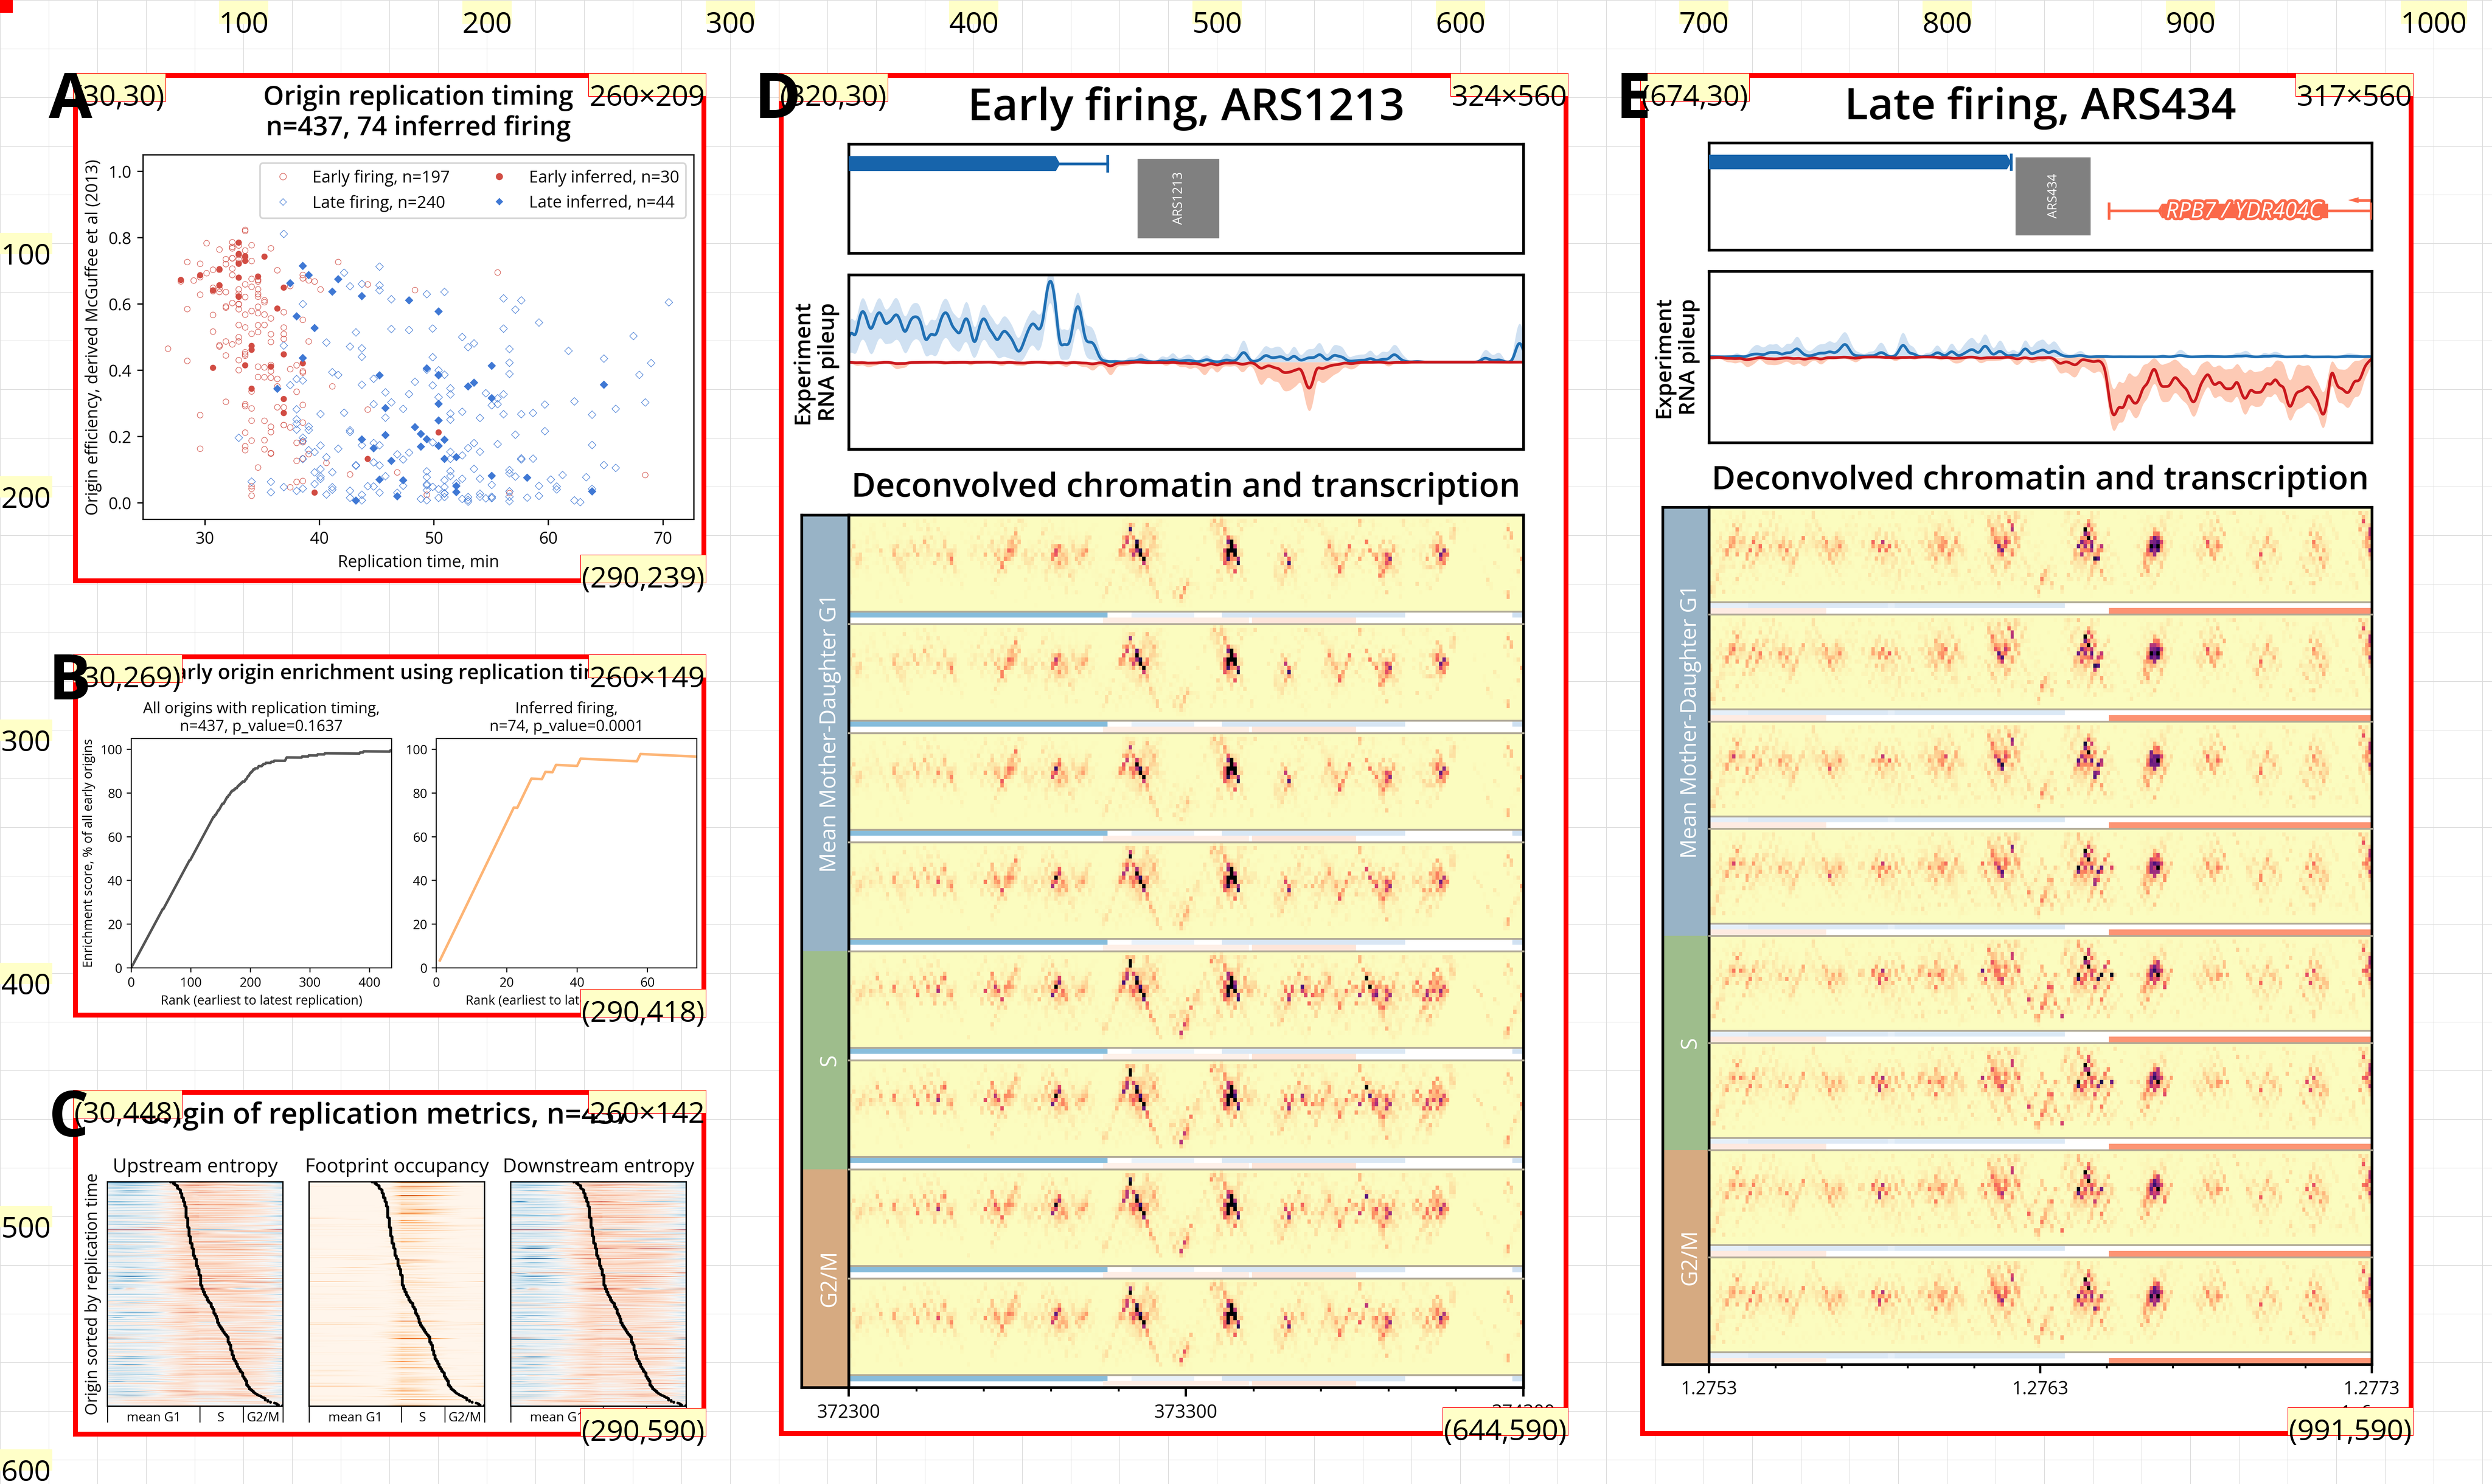

In [675]:
from IPython.display import Image, display
display(Image('output/draft4_run/Figures/Supplemental5.7_Origins_debug.png'))

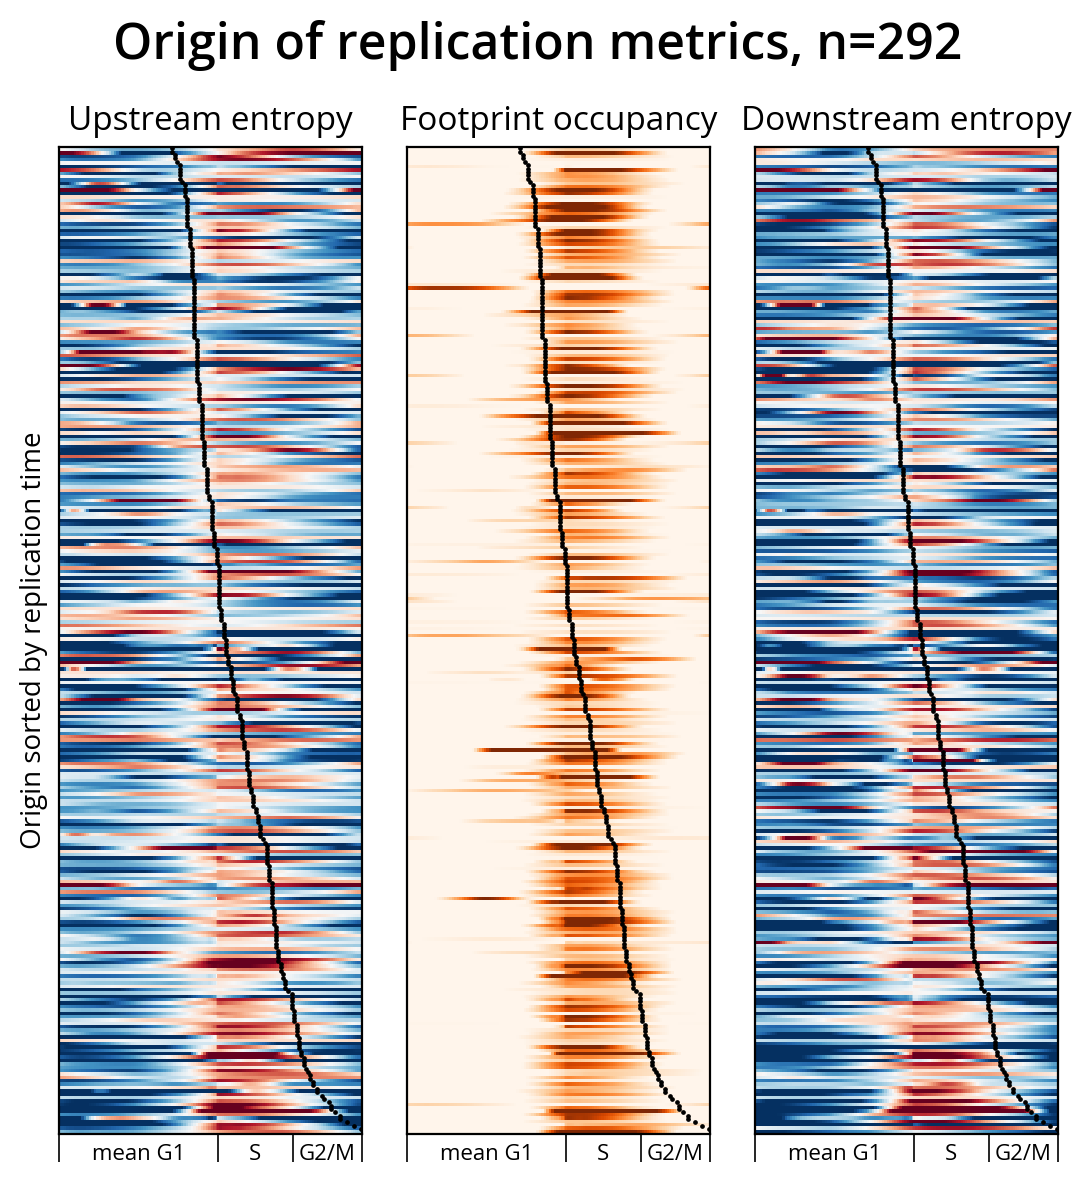

In [736]:
# Check a few things:
# 1. Why is there a gap of footprint signal for the middle replicating origins?
# 2. Where is the signal of entropic difference between early and late replicationg
#    origins we were previously seeing (and Yulong saw?)

origins = fig_origins.origin_timings
selected = origins[~(origins.footprint_class == 'no_footprint')]

fig_origins.origin_processor.plot_origin_metrics_heatmaps(selected.sort_values(
    'replication_time').index)


In [737]:
# Let's reproduce an analysis by loading the chromatin processor
# we can look at the lowest expressed genes, and the entropy for the nucleosomes
# of these genes sorted by replication

from pipeline.chromatin_metrics_processor import ChromatinMetricsProcessor

chromatin_processor = ChromatinMetricsProcessor('output/draft4_run/')

In [738]:
chromatin_processor.setup_data_loaders()

In [739]:
chromatin_processor.load_and_assign_saved_metrics()

Loading saved data from output/draft4_run//chromatin_metrics...
  Loading deconvolved data...
    Loaded promoter_occupancy: 9663 genes, 257 timepoints
    Loaded nucleosome_entropy: 9663 genes, 257 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 257 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep1 data...
    Loaded promoter_occupancy: 9663 genes, 16 timepoints
    Loaded nucleosome_entropy: 9663 genes, 16 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 16 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep2 data...
    Loaded promoter_occupancy: 9663 genes, 15 timepoints
    Loaded nucleosome_entropy: 9663 genes, 15 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 15 timepoints
    Loaded promoter_occupancy PTRs: 9663 gen

In [743]:
gene_nucleosome_entropy = chromatin_processor.deconvolved_chromatin_metrics[
    'nucleosome_entropy']
gene_nucleosome_entropy.head()

,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,256
transcript_name,,,,,,,,,,,,,,,,,,,,,
YAL068C,3.392523,3.392845,3.393488,3.394423,3.395658,3.397277,3.399297,3.401728,3.404576,3.407741,...,3.954921,3.940008,3.926056,3.913186,3.901411,3.891013,3.882261,3.875467,3.871950,4.765892
YAL067W-A,5.639428,5.641072,5.644260,5.648963,5.655053,5.661988,5.669607,5.677804,5.686451,5.695599,...,6.616415,6.607367,6.597514,6.587106,6.576092,6.565072,6.555219,6.547116,6.542876,6.165829
YAL067C,7.054568,7.055200,7.056436,7.058248,7.060607,7.063456,7.066759,7.070470,7.074553,7.078988,...,7.669727,7.667412,7.664647,7.661478,7.657889,7.654060,7.650418,7.647244,7.645515,7.406049
YAL065C,5.757472,5.758016,5.759096,5.760635,5.762657,5.765461,5.768933,5.773006,5.777602,5.782576,...,6.428720,6.416887,6.403653,6.389332,6.373883,6.358149,6.343575,6.331073,6.324462,6.380805
YAL064W-B,4.965983,4.967728,4.971452,4.977012,4.984364,4.993334,5.003920,5.015974,5.029468,5.044531,...,5.645337,5.640577,5.635554,5.630429,5.625189,5.620048,5.616001,5.613240,5.611904,5.670622


In [746]:
expression_data = fig_origins.expression_processor.expression_data
expression_data.head()

,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,256
transcript_name,,,,,,,,,,,,,,,,,,,,,
YAL068C,1.019523e-01,1.019404e-01,1.019164e-01,1.018804e-01,1.018324e-01,1.017725e-01,1.017006e-01,1.016170e-01,1.015215e-01,1.014133e-01,...,1.818338e-02,1.648960e-02,1.474086e-02,1.297629e-02,1.119432e-02,9.480378e-03,7.972193e-03,6.735290e-03,6.095734e-03,9.229450e-02
YAL067W-A,1.477840e-09,1.477800e-09,1.477724e-09,1.477595e-09,1.477415e-09,1.477232e-09,1.477049e-09,1.476861e-09,1.476672e-09,1.476476e-09,...,1.455398e-09,1.455301e-09,1.455196e-09,1.455088e-09,1.454979e-09,1.454874e-09,1.454809e-09,1.454771e-09,1.454779e-09,1.489557e-09
YAL067C,1.586884e+00,1.580607e+00,1.568464e+00,1.550212e+00,1.526477e+00,1.500683e+00,1.473696e+00,1.446137e+00,1.418700e+00,1.390511e+00,...,2.189374e+00,2.080855e+00,1.964823e+00,1.844674e+00,1.717644e+00,1.591059e+00,1.479950e+00,1.389999e+00,1.343227e+00,5.328558e+00
YAL065C,5.027270e-01,5.024736e-01,5.019703e-01,5.012147e-01,5.002129e-01,4.989916e-01,4.975574e-01,4.959183e-01,4.940805e-01,4.920331e-01,...,2.735859e-02,2.612627e-02,2.491968e-02,2.375457e-02,2.261676e-02,2.154716e-02,2.063712e-02,1.992125e-02,1.955187e-02,3.776325e-01
YAL064W-B,1.018470e+00,1.018463e+00,1.018449e+00,1.018428e+00,1.018400e+00,1.018365e+00,1.018323e+00,1.018273e+00,1.018217e+00,1.018158e+00,...,1.025924e+00,1.026316e+00,1.026723e+00,1.027133e+00,1.027549e+00,1.027950e+00,1.028298e+00,1.028578e+00,1.028723e+00,2.607579e+00


In [750]:
from src.transcripts_dataset import load_transcripts_sets

genesset, _ = load_transcripts_sets('output/draft4_run/')
gene_index = genesset.index

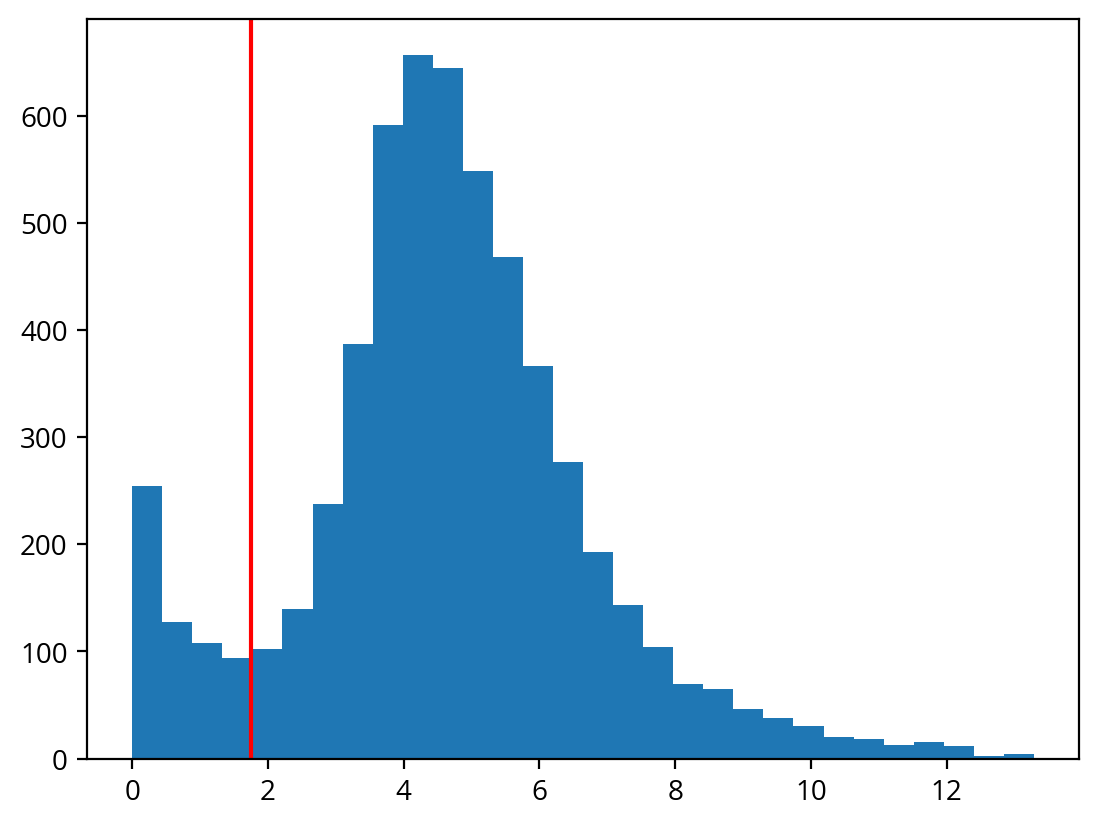

In [762]:
average_expression = expression_data.loc[gene_index][config1.t_indices()].mean(1)
plt.hist(average_expression, bins=30)
q10 = np.quantile(average_expression, q=0.1)
low_tx_genes = average_expression[average_expression < q10].index
plt.axvline(q10, c='red')

In [798]:
low_tx_entropy = gene_nucleosome_entropy.loc[low_tx_genes]
low_tx_entropy

# Sort by replication timing
low_geneset = genesset.loc[low_tx_genes]

#fig_origins.replication_timings

In [832]:
from src.mnase_10kb_loader import get_bin_for_position

geneset_replication_times = genesset.copy()
for index, gene in low_geneset.iterrows():
    chr_replication = fig_origins.replication_timings.replications_df.loc[gene.chr]
    closest_origin_bp = get_bin_for_position(gene.TSS, chr_replication.index.values,
        bp_only=True) 
    geneset_replication_times.loc[index, 'replication_time'] = \
        chr_replication.loc[closest_origin_bp].replication_time

geneset_replication_times = geneset_replication_times.loc[low_geneset.index].sort_values('replication_time')

Text(0.5, 1.0, 'All  genes, nucleosome\nentropy sorted by replication time')

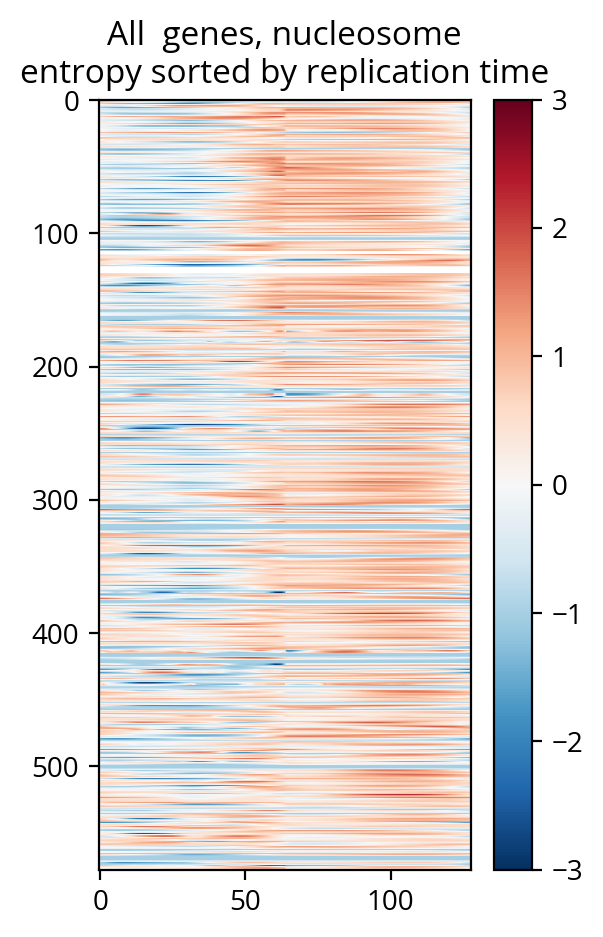

In [833]:
normalized_entropy = (gene_nucleosome_entropy - gene_nucleosome_entropy.mean(1).values[:, None])/\
    gene_nucleosome_entropy.std(1).values[:, None]
normalized_entropy.columns = normalized_entropy.columns.astype(int)

plt.figure(figsize=(3, 5))
plt.imshow(normalized_entropy[config1.b_indices()].loc[geneset_replication_times.index], 
    cmap='RdBu_r', vmin=-3, vmax=3, aspect='auto')
plt.colorbar()
plt.title("All  genes, nucleosome\nentropy sorted by replication time")

#plt.scatter(low_geneset_replication_times.replication_time+60, 
#    np.arange(len(low_geneset_replication_times)), s=1, c='black')

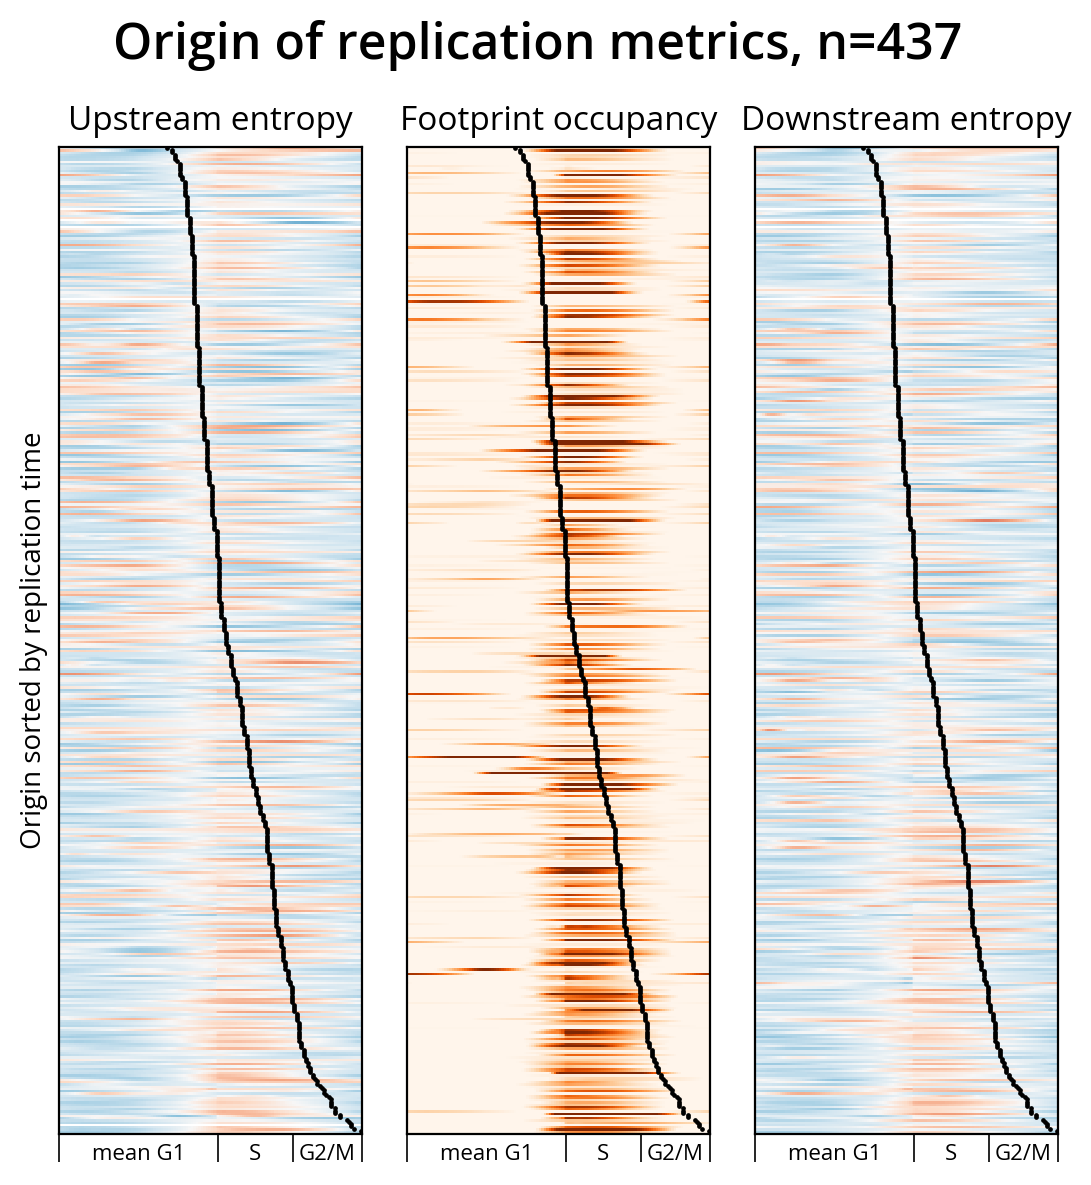

In [834]:
fig_origins.origin_processor.plot_origin_metrics_heatmaps()

In [836]:
from pipeline.fig_origins import FigureOrigins

fig_origins = FigureOrigins('output/draft4_run/')
fig_origins.setup_data()

Creating directory: output/draft4_run//figure_origins...Directory exists. Skipping.
Filtering the called replication timings to 1.0 percentile (highest timing indicative of poor fit)
Filtered timings from 5482 to 5370
Number of regions removed: 112
Correlation between muller and replication timing model: 0.87


In [837]:
fig_origins.setup_processors(force_recompute=True)

Creating directory: output/draft4_run//figure_origins/metrics...Directory exists. Skipping.
TODO: Testing if setting the nucleosome window to 2000 bp wide windows outside of the 500 bp window of origins will identify the replication timing relationship
Starting batch processing of 437 origins...
Detected 257 timepoints from sample origin oridb_5
1/437 00:00:00.543
101/437 00:00:46.383
201/437 00:01:30.635
301/437 00:02:15.171
401/437 00:02:58.679
Completed processing 437 origins!
Saving results to disk...
Results saved to output/draft4_run//figure_origins/metrics/
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints


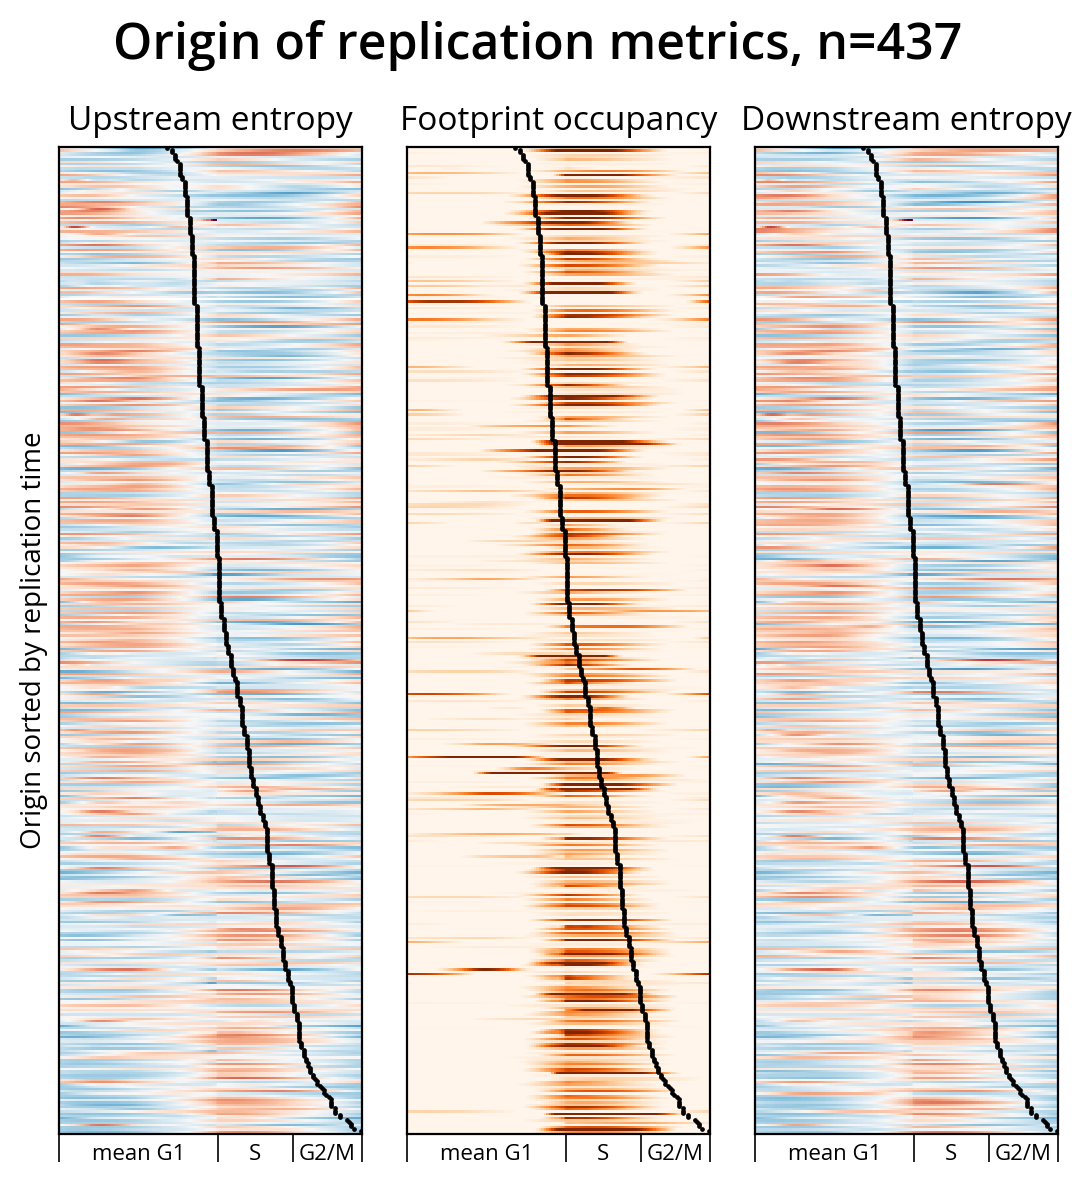

In [848]:
fig_origins.origin_processor.plot_origin_metrics_heatmaps()

In [846]:
fig_origins_original = FigureOrigins('output/draft4_run/')
fig_origins_original.setup_data()
fig_origins_original.setup_processors(force_recompute=True)


Creating directory: output/draft4_run//figure_origins...Directory exists. Skipping.
Filtering the called replication timings to 1.0 percentile (highest timing indicative of poor fit)
Filtered timings from 5482 to 5370
Number of regions removed: 112
Correlation between muller and replication timing model: 0.87
Creating directory: output/draft4_run//figure_origins/metrics...Directory exists. Skipping.
Starting batch processing of 437 origins...
Detected 257 timepoints from sample origin oridb_5
1/437 00:00:00.431
101/437 00:00:44.882
201/437 00:01:27.188
301/437 00:02:11.138
401/437 00:02:53.106
Completed processing 437 origins!
Saving results to disk...
Results saved to output/draft4_run//figure_origins/metrics/
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints


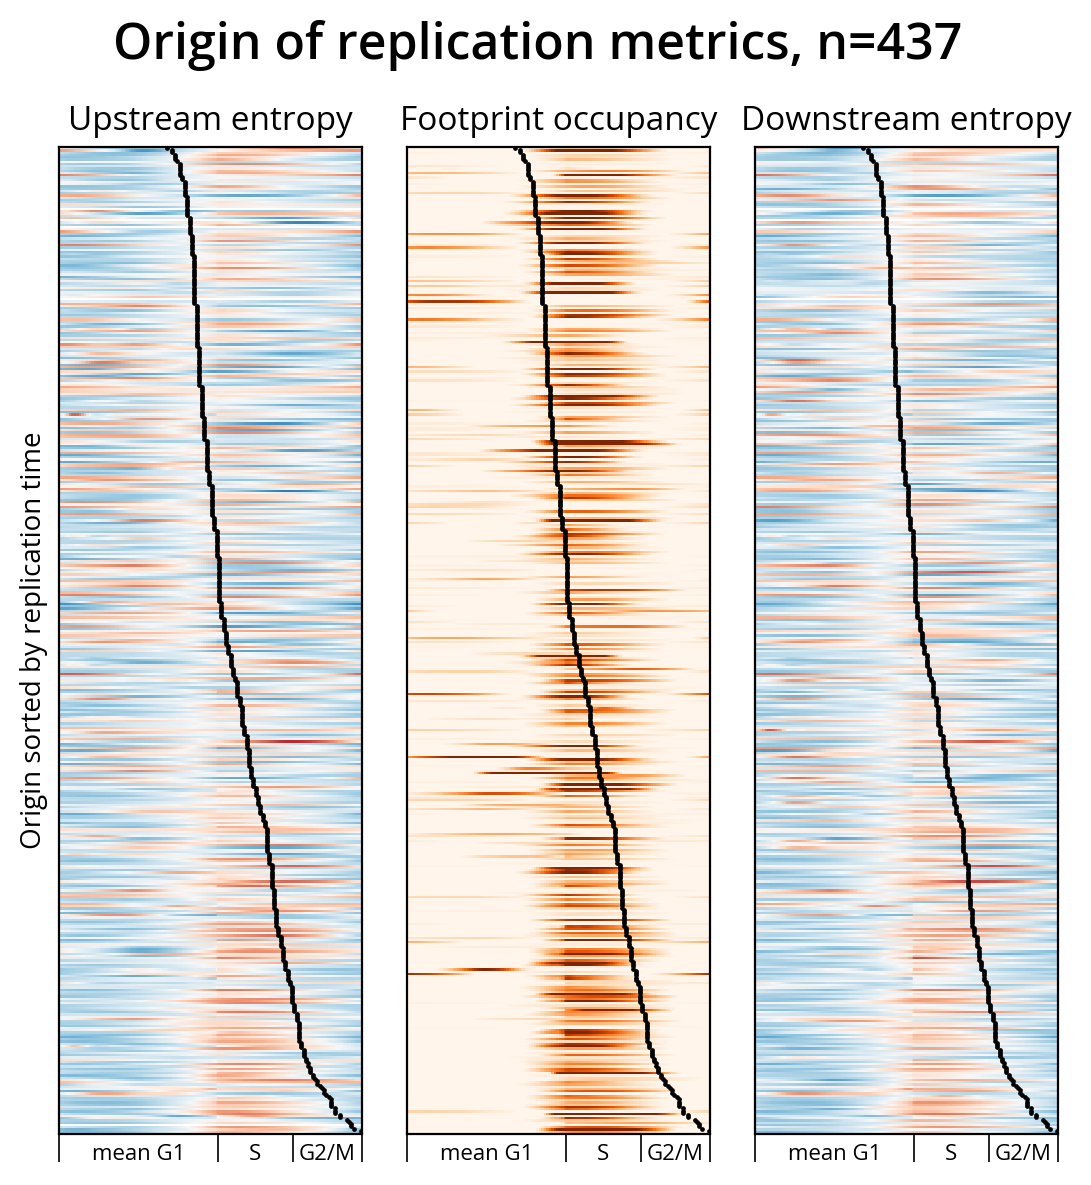

In [849]:
fig_origins_original.origin_processor.plot_origin_metrics_heatmaps()